# Model Performance Test on Russian Hate Speech

This notebook evaluates the performance of various ModernBERT models (KNN-based and Ensembles) on the Russian Hate Speech test set.

In [1]:
import os
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from checklist.pred_wrapper import PredictorWrapper
from checklist.test_types import MFT
import dataHandler as dh
from collections import Counter

# Set plot style
sns.set_theme(style="whitegrid")

In [2]:
def reset_cuda():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"CUDA available: {torch.cuda.get_device_name(0)}")
    else:
        print("CUDA not available, using CPU")

reset_cuda()
device = 0 if torch.cuda.is_available() else -1

CUDA available: NVIDIA GeForce RTX 4070


In [3]:
class HuggingFacePipelineWrapper(PredictorWrapper):
    def __init__(self, pipeline_classifier):
        self.pipeline = pipeline_classifier
        
    def __call__(self, texts):
        predictions = []
        confidences = []
        
        for text in texts:
            prediction = self.pipeline(text, truncation=True, max_length=512)
            if isinstance(prediction, list):
                prediction = prediction[0]
            
            label = prediction['label']
            score = prediction['score']
                
            predictions.append(label)
            confidences.append(score)
            
        return predictions, confidences

class EnsemblePipelineWrapper(PredictorWrapper):
    def __init__(self, pipelines):
        self.pipelines = pipelines
        
    def __call__(self, texts):
        final_predictions = []
        final_confidences = []
        
        for text in texts:
            votes = []
            scores = []
            
            for p in self.pipelines:
                prediction = p(text, truncation=True, max_length=512)
                if isinstance(prediction, list):
                    prediction = prediction[0]
                
                label = prediction['label']
                score = prediction['score']
                
                # Normalize label to int for voting
                if str(label).lower() in ['hate', 'label_1', '1']:
                    votes.append(1)
                else:
                    votes.append(0)
                
                # Store score (probability of the predicted class)
                scores.append(score)
            
            # Majority Vote
            count = Counter(votes)
            majority_label = count.most_common(1)[0][0]
            
            # Average confidence (this is a simplification, ideally we'd average logits)
            # For now, just taking average of scores is a proxy
            avg_score = np.mean(scores)
            
            # Convert back to string label if needed by CheckList (it handles both)
            final_predictions.append(majority_label)
            final_confidences.append(avg_score)
            
        return final_predictions, final_confidences

In [4]:
# Load Test Data
test_data = dh.getAnnotadedRussTest()
print(f"Loaded {len(test_data['text'])} test samples.")

# Convert labels to integers if they are strings
if isinstance(test_data['label'][0], str):
    print("Converting string labels to integers...")
    test_data['label'] = [1 if l == 'hate' else 0 for l in test_data['label']]
    
print(f"Sample label: {test_data['label'][0]}")

Loaded 996 test samples.
Converting string labels to integers...
Sample label: 0


In [8]:
# Model Discovery
base_dir = "models_knn_tox_refactored/"
models_to_eval = []

ensemble_include = False

def get_model_paths(base_path, dataset_name, model_type, model_name):
    # Check for 'final' subdirectory
    final_path = os.path.join(base_path, "final")
    if os.path.exists(final_path):
        model_path = final_path
    else:
        model_path = base_path
        
    # Check for 'tokenizer' subdirectory
    tokenizer_path = os.path.join(base_path, "tokenizer")
    if not os.path.exists(tokenizer_path):
        tokenizer_path = model_path
        
    return {
        "name": f"{model_name}-{dataset_name}",
        "path": model_path,
        "tokenizer_path": tokenizer_path,
        "type": model_type,
        "dataset": dataset_name
    }

for folder in os.listdir(base_dir):
    path = os.path.join(base_dir, folder)
    if os.path.isdir(path):
        model_name = folder.split("_")[1]
        # 1. KNN Models
        knn_dir = os.path.join(path, "knn")
        if os.path.exists(knn_dir):
            for d in os.listdir(knn_dir):
                path_knn = os.path.join(knn_dir, d)
                if os.path.isdir(path_knn):
                    models_to_eval.append(get_model_paths(path_knn, d, "KNN", model_name))

        ratio_dir = os.path.join(path, "knnratio_density_ratio_raw")
        if os.path.exists(ratio_dir):
            for d in os.listdir(ratio_dir):
                path_ratio = os.path.join(ratio_dir, d)
                if os.path.isdir(path_ratio):
                    models_to_eval.append(get_model_paths(path_ratio, d, "Ratio", model_name))

        ratio_dir = os.path.join(path, "knnratio_nodensity_raw_noout")
        if os.path.exists(ratio_dir):
            for d in os.listdir(ratio_dir):
                path_ratio = os.path.join(ratio_dir, d)
                if os.path.isdir(path_ratio):
                    models_to_eval.append(get_model_paths(path_ratio, d, "Baseline_NoDensity", model_name))

        # 2. Ensemble Models (Grouped)  
        if ensemble_include:
            ensemble_dir = os.path.join(path, "ensemble")
            ensemble_submodels = []
            if os.path.exists(ensemble_dir):
                for d in os.listdir(ensemble_dir):
                    path_ensemble = os.path.join(ensemble_dir, d)
                    if os.path.isdir(path_ensemble):
                        ensemble_submodels.append(get_model_paths(path_ensemble, d, "EnsembleSub", model_name))

            if ensemble_submodels:
                models_to_eval.append({
                    "name": f"Ensemble-{model_name}",
                    "type": "Ensemble",
                    "dataset": "Combined",
                    "submodels": ensemble_submodels
                })

# 3. Baseline (ModernBERT-base)
for folder in os.listdir(base_dir):
    parent, model = folder.split("_", 1)
    model_path = parent + "/" + model

    models_to_eval.append({
        "name": f"Baseline {model}",
        "path": model_path,
        "tokenizer_path": model_path,
        "type": "Baseline",
        "dataset": "Toxigen_All"
    })

print(f"Found {len(models_to_eval)} top-level models to evaluate.")
pd.DataFrame(models_to_eval)

Found 23 top-level models to evaluate.


,name,path,tokenizer_path,type,dataset
0,ModernBERT-base-k100,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,KNN,k100
1,ModernBERT-base-k1000,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,KNN,k1000
2,ModernBERT-base-k5,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,KNN,k5
3,ModernBERT-base-k1000_ratio,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,Ratio,k1000_ratio
4,ModernBERT-base-k100_ratio,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,Ratio,k100_ratio
5,ModernBERT-base-k5_ratio,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,Ratio,k5_ratio
6,ModernBERT-base-k100_ratio,models_knn_tox_refactored/answerdotai_ModernBE...,models_knn_tox_refactored/answerdotai_ModernBE...,Baseline_NoDensity,k100_ratio
7,deberta-v3-base-k100,models_knn_tox_refactored/microsoft_deberta-v3...,models_knn_tox_refactored/microsoft_deberta-v3...,KNN,k100
8,deberta-v3-base-k1000,models_knn_tox_refactored/microsoft_deberta-v3...,models_knn_tox_refactored/microsoft_deberta-v3...,KNN,k1000
9,deberta-v3-base-k5,models_knn_tox_refactored/microsoft_deberta-v3...,models_knn_tox_refactored/microsoft_deberta-v3...,KNN,k5


In [9]:
# Evaluation Loop
results_list = []

for model_info in models_to_eval:
    print(f"Evaluating {model_info['name']}...")
    try:
        wrapped_model = None
        classifier = None
        
        if model_info['type'] == 'Ensemble':
            print(f"Loading {len(model_info['submodels'])} sub-models for ensemble...")
            pipelines = []
            for sub in model_info['submodels']:
                p = pipeline(
                    "text-classification", 
                    model=sub['path'], 
                    tokenizer=sub['tokenizer_path'],
                    device=device,
                    truncation=True,
                    max_length=512
                )
                pipelines.append(p)
            wrapped_model = EnsemblePipelineWrapper(pipelines)
            
        else:
            classifier = pipeline(
                "text-classification", 
                model=model_info['path'], 
                tokenizer=model_info['tokenizer_path'],
                device=device,
                truncation=True,
                max_length=512
            )
            wrapped_model = HuggingFacePipelineWrapper(classifier)
        
        # Run MFT using CheckList
        mft = MFT(
            data=test_data['text'], 
            labels=test_data['label'], 
            name=f"Test-{model_info['name']}",
            capability="Hate Speech Detection"
        )
        
        mft.run(wrapped_model, overwrite=True)
        
        # Compute Metrics manually to ensure we get AUC etc.
        preds, confs = wrapped_model(test_data['text'])
        
        y_pred = []
        y_prob = []
        
        for p, c in zip(preds, confs):
            # Normalize labels to 0/1
            val = 0
            p_str = str(p).lower()
            if p_str in ['hate', 'label_1', '1']:
                val = 1
            
            y_pred.append(val)
            
            # Reconstruct probability of class 1
            # If predicted class is 1, prob is c. If 0, prob is 1-c.
            if val == 1:
                y_prob.append(c)
            else:
                y_prob.append(1.0 - c)
                
        y_true = test_data['label']
        
        acc = accuracy_score(y_true, y_pred)
        b_acc = balanced_accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = 0.5
        
        mft_stats = mft.get_stats()
        failure_rate = mft_stats.get("failure_rate", 0.0)
        
        results_list.append({
            "Model": model_info['name'],
            "Type": model_info['type'],
            "Dataset": model_info['dataset'],
            "Accuracy": acc,
            "Balanced Accuracy": b_acc,
            "F1 Score": f1,
            "AUC": auc,
            "Precision": prec,
            "Recall": rec,
            "MFT Failure Rate": failure_rate
        })
        
        # Clean up
        if classifier:
            del classifier
        if wrapped_model:
            del wrapped_model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"Failed to evaluate {model_info['name']}: {e}")
        import traceback
        traceback.print_exc()

print("Evaluation complete.")

df_results = pd.DataFrame(results_list)

df_results['key'] = df_results['Model'] + "_" + df_results['Type'] + "_" + df_results['Dataset']
df_results.to_csv(f"results/results_{pd.Timestamp.now().strftime('%Y-%m-%d_%H-%M-%S')}.csv", index=False)
df_results

Evaluating ModernBERT-base-k100...


Device set to use cuda:0


Predicting 996 examples


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Evaluating ModernBERT-base-k1000...


...

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\Alexandre\miniconda3\envs\llama_ssl\lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Device set to use cuda:0


Predicting 996 examples
Evaluating Baseline toxigen_roberta...


Device set to use cuda:0


Predicting 996 examples
Evaluation complete.


,Model,Type,Dataset,Accuracy,Balanced Accuracy,F1 Score,AUC,Precision,Recall,MFT Failure Rate,key
0,ModernBERT-base-k100,KNN,k100,0.684739,0.761792,0.539589,0.854068,0.386555,0.893204,0.0,ModernBERT-base-k100_KNN_k100
1,ModernBERT-base-k1000,KNN,k1000,0.692771,0.768649,0.547337,0.845766,0.393617,0.898058,0.0,ModernBERT-base-k1000_KNN_k1000
2,ModernBERT-base-k5,KNN,k5,0.685743,0.767808,0.544396,0.849220,0.388773,0.907767,0.0,ModernBERT-base-k5_KNN_k5
3,ModernBERT-base-k1000_ratio,Ratio,k1000_ratio,0.692771,0.779415,0.555233,0.850479,0.396266,0.927184,0.0,ModernBERT-base-k1000_ratio_Ratio_k1000_ratio
4,ModernBERT-base-k100_ratio,Ratio,k100_ratio,0.699799,0.774874,0.554396,0.854891,0.400000,0.902913,0.0,ModernBERT-base-k100_ratio_Ratio_k100_ratio
5,ModernBERT-base-k5_ratio,Ratio,k5_ratio,0.690763,0.770972,0.548387,0.848495,0.392857,0.907767,0.0,ModernBERT-base-k5_ratio_Ratio_k5_ratio
6,ModernBERT-base-k100_ratio,Baseline_NoDensity,k100_ratio,0.687751,0.767279,0.544656,0.848673,0.389937,0.902913,0.0,ModernBERT-base-k100_ratio_Baseline_NoDensity_...
7,deberta-v3-base-k100,KNN,k100,0.687751,0.776250,0.551227,0.859681,0.392197,0.927184,0.0,deberta-v3-base-k100_KNN_k100
8,deberta-v3-base-k1000,KNN,k1000,0.689759,0.777516,0.552822,0.854329,0.393814,0.927184,0.0,deberta-v3-base-k1000_KNN_k1000
9,deberta-v3-base-k5,KNN,k5,0.687751,0.781633,0.555079,0.851201,0.393509,0.941748,0.0,deberta-v3-base-k5_KNN_k5


In [28]:
df_results['Model Family'] = (
    df_results['Model']
        .str.replace('Baseline ', '', regex=False)
        .str.split('-')
        .str[0]
        .str.split('_')
        .str[0]
)


In [29]:
df_results

,Model,Type,Dataset,Accuracy,Balanced Accuracy,F1 Score,AUC,Precision,Recall,MFT Failure Rate,key,Model Family
0,ModernBERT-base-k100,KNN,k100,0.684739,0.761792,0.539589,0.854068,0.386555,0.893204,0.0,ModernBERT-base-k100_KNN_k100,ModernBERT
1,ModernBERT-base-k1000,KNN,k1000,0.692771,0.768649,0.547337,0.845766,0.393617,0.898058,0.0,ModernBERT-base-k1000_KNN_k1000,ModernBERT
2,ModernBERT-base-k5,KNN,k5,0.685743,0.767808,0.544396,0.849220,0.388773,0.907767,0.0,ModernBERT-base-k5_KNN_k5,ModernBERT
3,ModernBERT-base-k1000_ratio,Ratio,k1000_ratio,0.692771,0.779415,0.555233,0.850479,0.396266,0.927184,0.0,ModernBERT-base-k1000_ratio_Ratio_k1000_ratio,ModernBERT
4,ModernBERT-base-k100_ratio,Ratio,k100_ratio,0.699799,0.774874,0.554396,0.854891,0.400000,0.902913,0.0,ModernBERT-base-k100_ratio_Ratio_k100_ratio,ModernBERT
5,ModernBERT-base-k5_ratio,Ratio,k5_ratio,0.690763,0.770972,0.548387,0.848495,0.392857,0.907767,0.0,ModernBERT-base-k5_ratio_Ratio_k5_ratio,ModernBERT
6,ModernBERT-base-k100_ratio,Baseline_NoDensity,k100_ratio,0.687751,0.767279,0.544656,0.848673,0.389937,0.902913,0.0,ModernBERT-base-k100_ratio_Baseline_NoDensity_...,ModernBERT
7,deberta-v3-base-k100,KNN,k100,0.687751,0.776250,0.551227,0.859681,0.392197,0.927184,0.0,deberta-v3-base-k100_KNN_k100,deberta
8,deberta-v3-base-k1000,KNN,k1000,0.689759,0.777516,0.552822,0.854329,0.393814,0.927184,0.0,deberta-v3-base-k1000_KNN_k1000,deberta
9,deberta-v3-base-k5,KNN,k5,0.687751,0.781633,0.555079,0.851201,0.393509,0.941748,0.0,deberta-v3-base-k5_KNN_k5,deberta


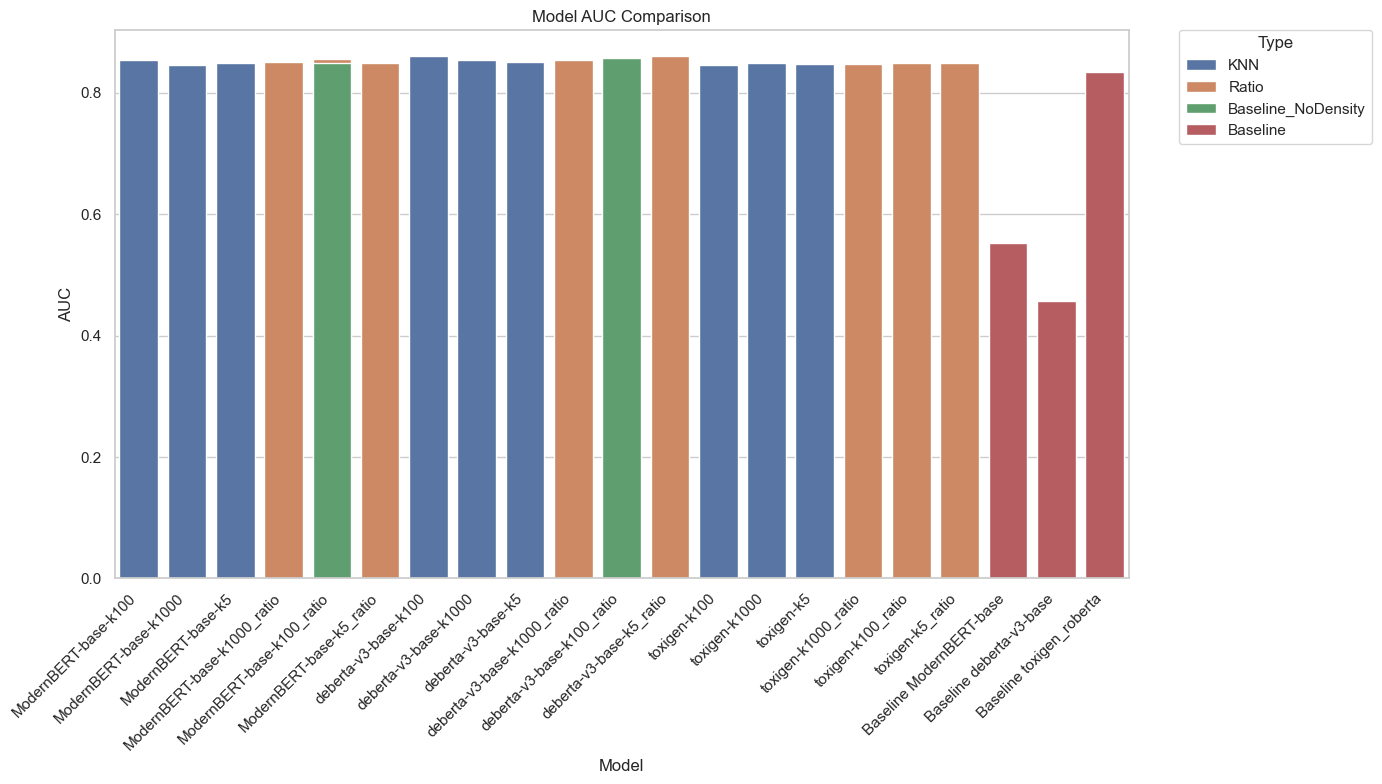

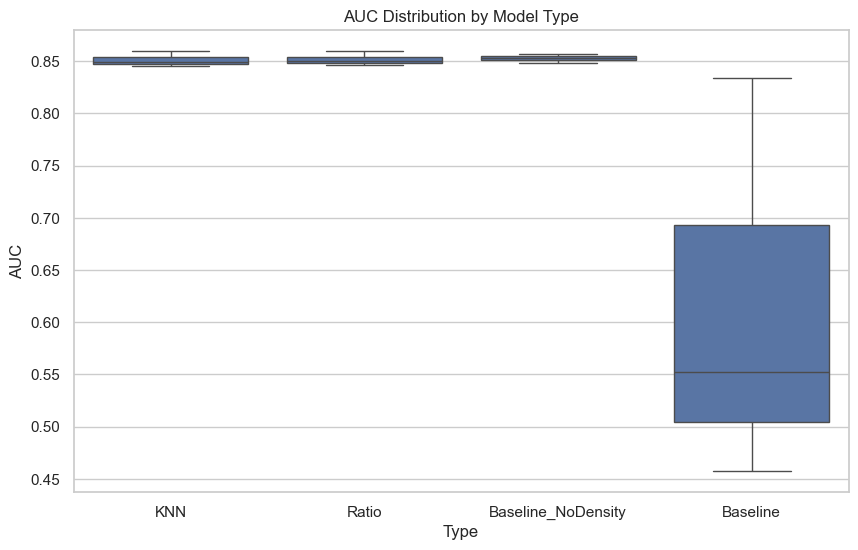

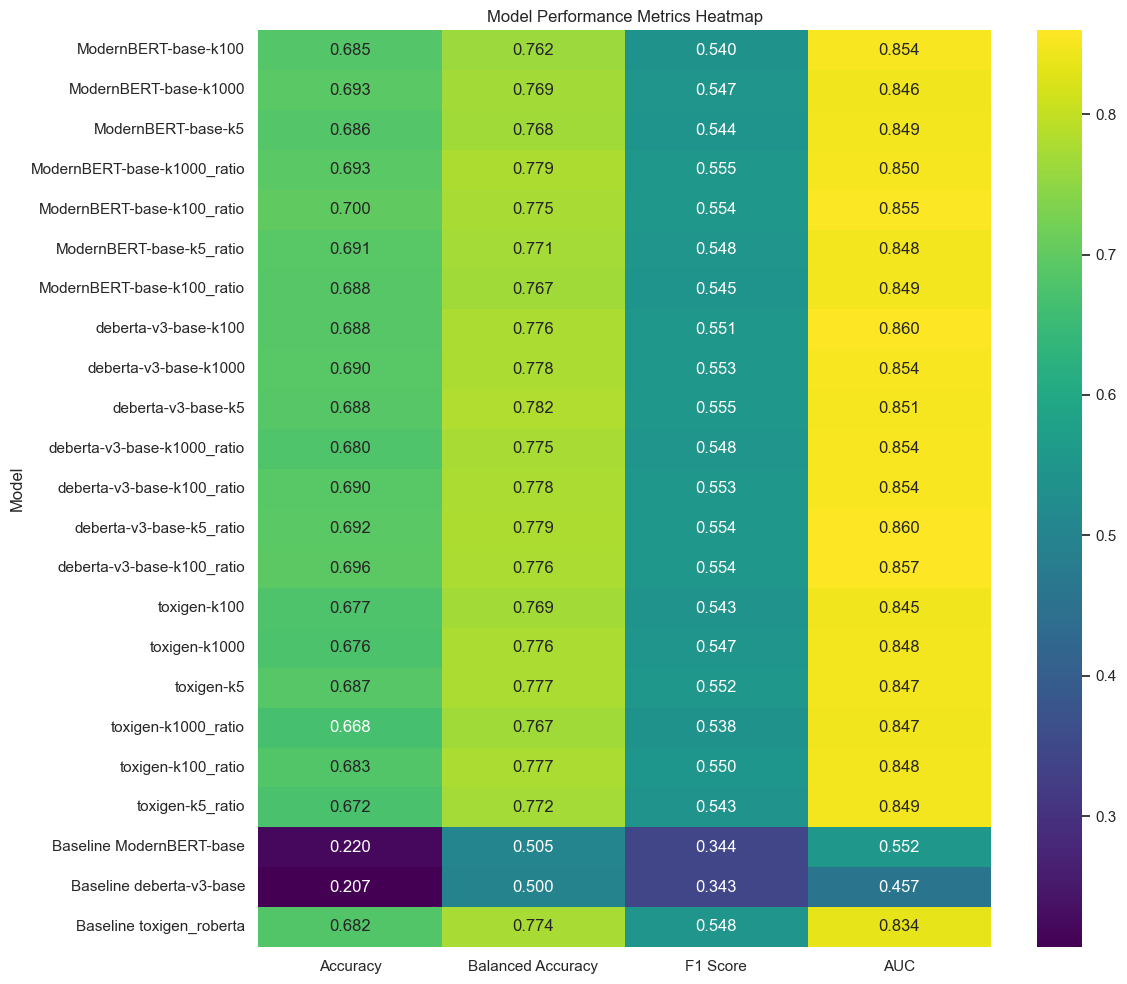

In [11]:
# Visualization

# get most recent results in folder results
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

path_results = ''

if path_results == '':
    # get most recent results file
    results_files = glob.glob('results/*.csv')
    results_files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    results_file = results_files[0]
    df_results = pd.read_csv(results_file)

# Plot 1: AUCROC Score Comparison
plt.figure(figsize=(14, 8))
sns.barplot(data=df_results, x='Model', y='AUC', hue='Type', dodge=False)
plt.xticks(rotation=45, ha='right')
plt.title("Model AUC Comparison")

# Move legend outside the plot (right side)
plt.legend(
    title="Type",
    bbox_to_anchor=(1.05, 1),   # position legend outside
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

# Plot 2: AUC Distribution by Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, x='Type', y='AUC')
plt.title("AUC Distribution by Model Type")
plt.show()

# Plot 3: Metrics Heatmap
plt.figure(figsize=(12, 10))
heatmap_data = df_results.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'F1 Score', 'AUC']]
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f')
plt.title("Model Performance Metrics Heatmap")
plt.tight_layout()
plt.show()